# Stimulus Alignment — Local-Global Oddball Dataset

## Paradigm structure
Each block contains 25 sequences of 5 stimuli: **`[A, A, A, B, blank]`**

| Position | Stimulus | Local condition | Global condition |
|---|---|---|---|
| 1–3 | Block-standard orientation (A) | standard | — |
| 4 | Usually other orientation (B) | **deviant** | standard (LD/GS) |
| 4 | Sometimes same orientation (A) | **standard** | **deviant** (LS/GD) |
| 5 | Blank (NaN) | — | — |

Block 1 is pure habituation (only LD/GS at position 4 — no global deviants).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import pynwb
import matplotlib.pyplot as plt

DATA_ROOT = Path("/home/kati/Data/000253")
subject_dir = DATA_ROOT / "sub-621890"

session_path = next(subject_dir.glob("*_ogen.nwb"))
session_io   = pynwb.NWBHDF5IO(session_path, mode="r", load_namespaces=True)
session      = session_io.read()

units    = session.units.to_dataframe()
good_units = units[units.quality == "good"].copy()

gratings_raw = session.intervals["init_grating_presentations"].to_dataframe()
print(f"Loaded: {len(good_units)} good units, {len(gratings_raw)} grating presentations")

Loaded: 2051 good units, 6035 grating presentations


## 1. Parse stimulus table — label trial types

In [2]:
def label_gratings(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add sequence-level condition labels to the grating presentations table.

    Within each block, stimuli arrive in groups of 5: [A, A, A, B, blank].
    - seq_position   : 1-indexed position within the 5-stimulus sequence
    - seq_idx        : which sequence within the block (0-indexed)
    - block_std_ori  : the standard (majority) orientation for that block
    - local_cond     : 'standard' | 'deviant' | 'blank'
    - global_cond    : 'standard' | 'deviant' | None  (only meaningful at position 4)
    - trial_type     : readable combination, e.g. 'LS/GD', 'LD/GS', 'local_std', 'blank'
    """
    rows = []
    for blk, sub in df.groupby("stimulus_block"):
        sub = sub.sort_values("start_time").reset_index()
        ori = sub["orientation"].values

        # Block standard = most common non-NaN orientation
        non_nan = pd.Series(ori).dropna()
        blk_std = non_nan.mode()[0] if len(non_nan) else np.nan

        seq_len = 5
        for i, row in sub.iterrows():
            pos = (i % seq_len) + 1          # 1-based position in sequence
            seq = i // seq_len
            o   = ori[i]

            if pos in (1, 2, 3):
                local  = "standard"
                glob   = None
                ttype  = "local_std"
            elif pos == 4:
                if pd.isna(o):               # edge case: blank at pos 4
                    local, glob, ttype = "blank", None, "blank"
                elif o != blk_std:           # local deviant, globally expected
                    local, glob, ttype = "deviant", "standard", "LD/GS"
                else:                        # local standard, globally deviant
                    local, glob, ttype = "standard", "deviant", "LS/GD"
            else:                            # pos == 5, blank
                local, glob, ttype = "blank", None, "blank"

            rows.append({
                **row.to_dict(),
                "block_std_ori": blk_std,
                "seq_idx":       seq,
                "seq_position":  pos,
                "local_cond":    local,
                "global_cond":   glob,
                "trial_type":    ttype,
            })

    return pd.DataFrame(rows).sort_values("start_time").reset_index(drop=True)


gratings = label_gratings(gratings_raw)

print("Trial type counts:")
print(gratings.trial_type.value_counts().to_string())
print(f"\nBlocks with global deviants: "
      f"{(gratings[gratings.trial_type=='LS/GD'].stimulus_block.nunique())} / "
      f"{gratings.stimulus_block.nunique()}")

Trial type counts:
trial_type
local_std    3621
blank        1207
LD/GS         841
LS/GD         366

Blocks with global deviants: 49 / 50


## 2. Spike alignment

`align_spikes` returns a **ragged list** (for rasters) and a **binned matrix** (for PSTHs) aligned to a set of event onset times.

In [3]:
def align_spikes(spike_times: np.ndarray,
                 event_times: np.ndarray,
                 t_before: float,
                 t_after: float,
                 bin_size: float = 0.01) -> dict:
    """
    Align spike times to events.

    Returns
    -------
    dict with:
      'raster'  : list of arrays, one per trial — spike times relative to event onset
      'psth'    : (n_trials, n_bins) bool array — 1 where a spike occurred
      'bins'    : bin centre times (seconds, relative to event onset)
      'rate'    : (n_bins,) mean firing rate across trials (spikes/s)
    """
    bins = np.arange(-t_before, t_after + bin_size, bin_size)
    bin_centres = bins[:-1] + bin_size / 2

    raster = []
    psth   = np.zeros((len(event_times), len(bin_centres)), dtype=bool)

    for i, t0 in enumerate(event_times):
        window = spike_times[(spike_times >= t0 - t_before) &
                             (spike_times <  t0 + t_after)]
        rel = window - t0
        raster.append(rel)
        counts, _ = np.histogram(rel, bins=bins)
        psth[i] = counts.astype(bool)

    rate = psth.mean(axis=0) / bin_size   # spikes/s

    return {"raster": raster, "psth": psth, "bins": bin_centres, "rate": rate}


# --- quick test on one unit ---
T_BEFORE = 0.1   # s before stimulus onset
T_AFTER  = 0.5   # s after  (covers the full 500 ms stimulus)
BIN_SIZE = 0.01  # 10 ms bins

uid = good_units.index[42]    # pick an arbitrary unit
st  = session.units["spike_times"][uid]

# Use LD/GS trials (excluding habituation block 1)
ldgs_onsets = gratings.loc[
    (gratings.trial_type == "LD/GS") & (gratings.stimulus_block > 1),
    "start_time"
].values

result = align_spikes(st, ldgs_onsets, T_BEFORE, T_AFTER, BIN_SIZE)
print(f"Unit {uid}  |  {len(ldgs_onsets)} LD/GS trials")
print(f"PSTH shape : {result['psth'].shape}")
print(f"Peak rate  : {result['rate'].max():.1f} spikes/s")

Unit 73  |  816 LD/GS trials
PSTH shape : (816, 60)
Peak rate  : 0.9 spikes/s


## 3. LFP alignment

`align_lfp` slices a time window around each event and returns a `(n_trials, n_samples, n_channels)` array. Reads lazily from HDF5 — only loads the requested windows.

In [4]:
def align_lfp(lfp_data,
              lfp_t: np.ndarray,
              event_times: np.ndarray,
              t_before: float,
              t_after: float,
              channel_idx=None) -> dict:
    """
    Align LFP to events.

    Parameters
    ----------
    lfp_data    : HDF5 dataset or array, shape (n_samples, n_channels)
    lfp_t       : timestamps array (seconds), shape (n_samples,)
    event_times : event onset times (seconds)
    t_before    : seconds before event
    t_after     : seconds after event
    channel_idx : array of channel indices to load (None = all)

    Returns
    -------
    dict with:
      'erp'     : (n_trials, n_window_samples, n_channels) float32  [Volts]
      'time'    : window time axis relative to event onset (seconds)
      'fs'      : estimated sampling rate (Hz)
    """
    fs = 1.0 / np.median(np.diff(lfp_t[:10_000]))
    n_pre  = int(np.round(t_before * fs))
    n_post = int(np.round(t_after  * fs))
    n_win  = n_pre + n_post
    time   = np.arange(-n_pre, n_post) / fs

    if channel_idx is None:
        n_ch = lfp_data.shape[1]
        channel_idx = np.arange(n_ch)

    erp = np.full((len(event_times), n_win, len(channel_idx)),
                  np.nan, dtype=np.float32)

    for i, t0 in enumerate(event_times):
        centre = int(np.searchsorted(lfp_t, t0))
        i0 = centre - n_pre
        i1 = centre + n_post
        if i0 < 0 or i1 > len(lfp_t):
            continue
        erp[i] = lfp_data[i0:i1, :][:, channel_idx]

    return {"erp": erp, "time": time, "fs": fs}


# Open a probe file and align LFP to LD/GS and LS/GD onsets
probe_path = next(subject_dir.glob("*_probe-2_ecephys.nwb"))
probe_io   = pynwb.NWBHDF5IO(probe_path, mode="r", load_namespaces=True)
probe_nwb  = probe_io.read()
lfp_es     = probe_nwb.acquisition["probe_2_lfp"].electrical_series["probe_2_lfp_data"]
lfp_t      = lfp_es.timestamps[()]
electrodes = probe_nwb.electrodes.to_dataframe()

# Use valid channels only
valid_ch = np.where(electrodes.valid_data.values)[0]
print(f"Valid channels: {len(valid_ch)} / {len(electrodes)}")
print(f"Brain areas   : {electrodes.iloc[valid_ch].location.unique().tolist()}")

Valid channels: 276 / 276
Brain areas   : ['SCig', 'POST', 'VISp6b', 'VISp6a', 'VISp5', 'VISp4', 'VISp2/3', 'VISp1', 'root']


In [5]:
# Compute ERP for LD/GS and LS/GD (exclude habituation block 1)
test_blocks = gratings.stimulus_block > 1

ldgs_onsets = gratings.loc[test_blocks & (gratings.trial_type == "LD/GS"), "start_time"].values
lsgd_onsets = gratings.loc[test_blocks & (gratings.trial_type == "LS/GD"), "start_time"].values

print(f"Aligning LFP: {len(ldgs_onsets)} LD/GS trials, {len(lsgd_onsets)} LS/GD trials ...")

lfp_ldgs = align_lfp(lfp_es.data, lfp_t, ldgs_onsets, T_BEFORE, T_AFTER, channel_idx=valid_ch)
lfp_lsgd = align_lfp(lfp_es.data, lfp_t, lsgd_onsets, T_BEFORE, T_AFTER, channel_idx=valid_ch)

print(f"ERP arrays: {lfp_ldgs['erp'].shape}  (trials × samples × channels)")
print(f"Estimated LFP Fs: {lfp_ldgs['fs']:.1f} Hz")

Aligning LFP: 816 LD/GS trials, 366 LS/GD trials ...


ERP arrays: (816, 750, 276)  (trials × samples × channels)
Estimated LFP Fs: 1250.0 Hz


## 4. Plots — PSTH and ERP by condition

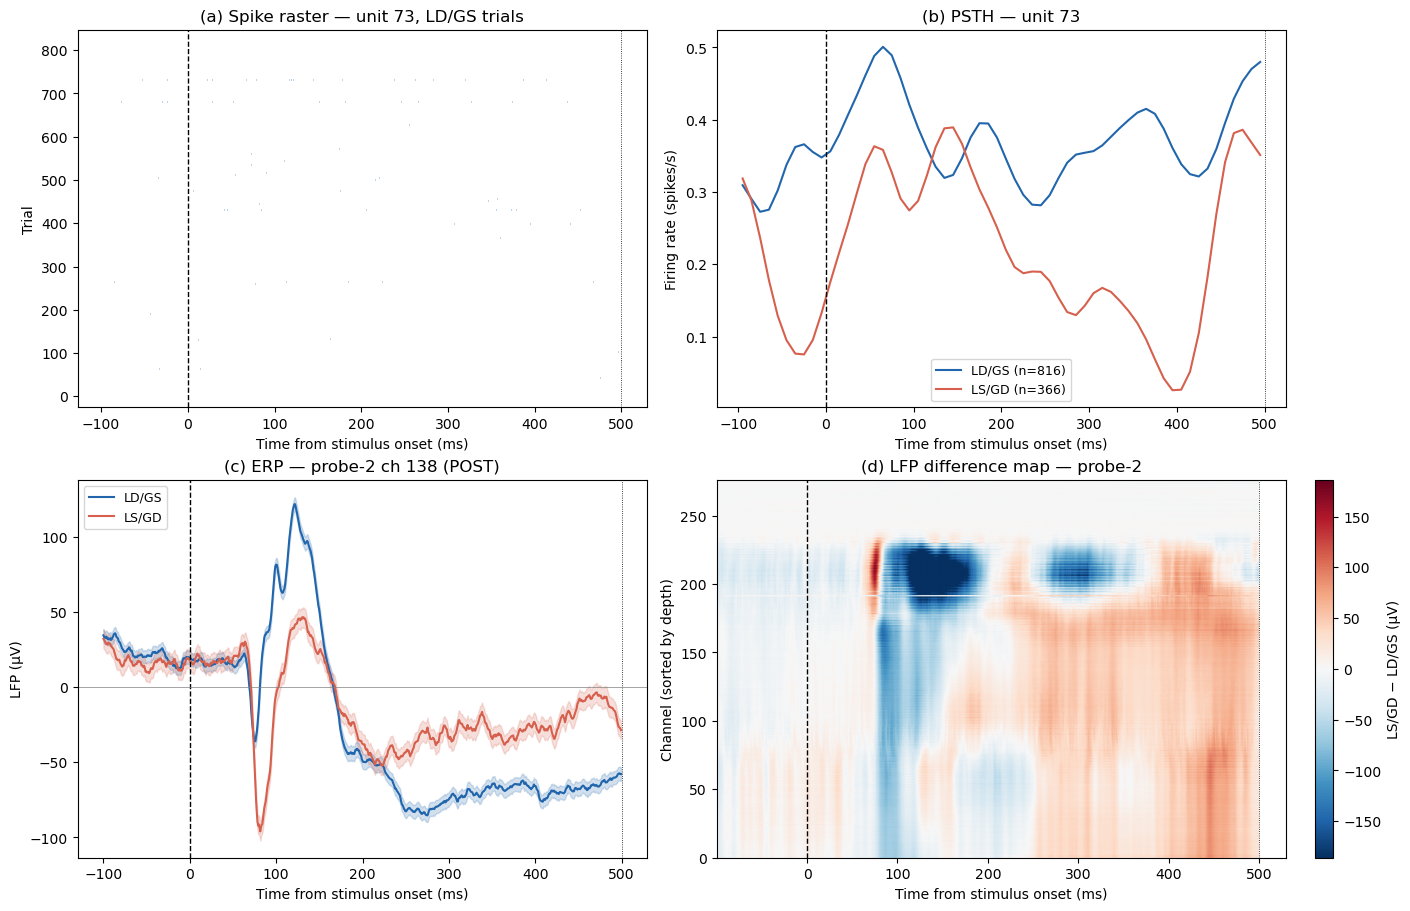

In [6]:
def smooth_psth(rate: np.ndarray, bins: np.ndarray, sigma_ms: float = 20) -> np.ndarray:
    """Gaussian-smooth a PSTH rate vector. sigma_ms in milliseconds."""
    from scipy.ndimage import gaussian_filter1d
    bin_ms = np.median(np.diff(bins)) * 1000
    sigma_bins = sigma_ms / bin_ms
    return gaussian_filter1d(rate.astype(float), sigma=sigma_bins)


COLORS = {"LD/GS": "#2166ac", "LS/GD": "#d6604d"}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

# ── (a) Spike raster — one unit, LD/GS ───────────────────────────────────────
ax = axes[0, 0]
r_ldgs = align_spikes(session.units["spike_times"][uid], ldgs_onsets, T_BEFORE, T_AFTER, BIN_SIZE)
for trial, spikes in enumerate(r_ldgs["raster"]):
    ax.vlines(spikes * 1000, trial, trial + 0.8, lw=0.4, color=COLORS["LD/GS"])
ax.axvline(0, color="k", lw=1, ls="--")
ax.axvline(500, color="k", lw=0.6, ls=":")
ax.set(xlabel="Time from stimulus onset (ms)", ylabel="Trial",
       title=f"(a) Spike raster — unit {uid}, LD/GS trials")

# ── (b) PSTH — LD/GS vs LS/GD, single unit ───────────────────────────────────
ax = axes[0, 1]
for ttype, onsets in [("LD/GS", ldgs_onsets), ("LS/GD", lsgd_onsets)]:
    res = align_spikes(session.units["spike_times"][uid], onsets, T_BEFORE, T_AFTER, BIN_SIZE)
    smoothed = smooth_psth(res["rate"], res["bins"])
    ax.plot(res["bins"] * 1000, smoothed, color=COLORS[ttype], label=f"{ttype} (n={len(onsets)})")
ax.axvline(0, color="k", lw=1, ls="--")
ax.axvline(500, color="k", lw=0.6, ls=":")
ax.set(xlabel="Time from stimulus onset (ms)", ylabel="Firing rate (spikes/s)",
       title=f"(b) PSTH — unit {uid}")
ax.legend(fontsize=9)

# ── (c) ERP — mean LFP trace, one channel, LD/GS vs LS/GD ───────────────────
ax = axes[1, 0]
ch_plot = len(valid_ch) // 2    # middle channel
area    = electrodes.iloc[valid_ch[ch_plot]]["location"]
t_ms    = lfp_ldgs["time"] * 1000

mean_ldgs = np.nanmean(lfp_ldgs["erp"][:, :, ch_plot], axis=0) * 1e6
mean_lsgd = np.nanmean(lfp_lsgd["erp"][:, :, ch_plot], axis=0) * 1e6
sem_ldgs  = np.nanstd(lfp_ldgs["erp"][:, :, ch_plot], axis=0) * 1e6 / np.sqrt(len(ldgs_onsets))
sem_lsgd  = np.nanstd(lfp_lsgd["erp"][:, :, ch_plot], axis=0) * 1e6 / np.sqrt(len(lsgd_onsets))

for mean, sem, ttype, col in [(mean_ldgs, sem_ldgs, "LD/GS", COLORS["LD/GS"]),
                               (mean_lsgd, sem_lsgd, "LS/GD", COLORS["LS/GD"])]:
    ax.plot(t_ms, mean, color=col, label=ttype)
    ax.fill_between(t_ms, mean - sem, mean + sem, color=col, alpha=0.2)

ax.axvline(0,   color="k", lw=1, ls="--")
ax.axvline(500, color="k", lw=0.6, ls=":")
ax.axhline(0,   color="gray", lw=0.5)
ax.set(xlabel="Time from stimulus onset (ms)", ylabel="LFP (µV)",
       title=f"(c) ERP — probe-2 ch {valid_ch[ch_plot]} ({area})")
ax.legend(fontsize=9)

# ── (d) ERP channel map — mean LFP difference (LS/GD − LD/GS) across channels
ax = axes[1, 1]
diff_mean = (np.nanmean(lfp_lsgd["erp"], axis=0) -
             np.nanmean(lfp_ldgs["erp"], axis=0)) * 1e6   # (n_samples, n_valid_ch)
depth = electrodes.iloc[valid_ch]["probe_vertical_position"].values
sort_idx = np.argsort(depth)

im = ax.imshow(diff_mean[:, sort_idx].T,
               aspect="auto",
               extent=[t_ms[0], t_ms[-1], 0, len(valid_ch)],
               origin="lower", cmap="RdBu_r",
               vmin=-np.percentile(np.abs(diff_mean), 99),
               vmax= np.percentile(np.abs(diff_mean), 99))
ax.axvline(0,   color="k", lw=1, ls="--")
ax.axvline(500, color="k", lw=0.6, ls=":")
plt.colorbar(im, ax=ax, label="LS/GD − LD/GS (µV)")
ax.set(xlabel="Time from stimulus onset (ms)", ylabel="Channel (sorted by depth)",
       title="(d) LFP difference map — probe-2")

plt.savefig("stimulus_alignment.png", dpi=130)
plt.show()

In [7]:
session_io.close()
probe_io.close()